# Caden Stuff
#### Purpose
Stuff for Caden.

## Data for Statistics Project

In [2]:
### Boilerplate ###
## Boiler Plate that is required to run to make any cell below this work ##
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/dbarker7752/py21cmsig")
import py21cmsig
from pylinex import BasisSum, MetaFitter, AttributeQuantity, TrainedBasis, RepeatExpander, NullExpander, Forecaster, CompiledQuantity, \
    NLFitter,Sampler, LoadableModel
from tqdm import tqdm
import healpy as hp
from scipy import stats
from scipy.optimize import fsolve
from importlib import reload
import scipy
import perses
import copy
import camb

# Some basic constants
kb = 1.3807e-16    # Boltzman's constant [ergs per Kelvin]
kb_ev = 8.617e-5   # Boltzman's constant [electron volts per Kelvin]
h_pl = 6.6260755e-27 # Planck's constant [erg seconds]
c = 3e10        # speed of light [cm/s]
# Parameters  (Taking the Lambda CDM ones from Planck collaboration 2020 pg.19 (without BAO because of no real reason))
H0 = 67.49 # Hubble constant 
h = H0/100     # H0
omM0h2 = 0.1430
omB0h2 = 0.02237
omC0h2 = 0.1200  # Omega cold dark matter today 
omM0 = 0.1430/h**2   # Omega matter today
omB0 = 0.02237/h**2   # Omega baryons today 
omK0 = 0        # Omega curvature today
# omC0 = 0.1200/h**2   # Omega cold dark matter today 
omC0 = omM0-omB0
#omR0 = 8.98e-5  # Omega radiation today
omR0=8.600000001024455e-05  # Omega radiation from 21cm FAST
omL0 = 0.6847   # Omega Dark Energy today
f_He = 0.08    # Fraction of Helium by number
y_P = 0.2454  # Fraction of helium by mass (from Planck VI 2018) 
p_crit = 1.88e-29*h**2  # [g/cm^3] The critical density of the universe
p_crit_ergs = p_crit*8.99e20  #[ergs/cm^3]
m_p = 1.6727e-24   #[g]  mass of a proton
m_pMev = 938.28   # [MeV/c^2] mass of a proton
m_e = 9.1094e-28   #[g]  mass of an electron
m_eMev = 0.511      # [Mev/c^2] mass of an electron
m_He = 6.644e-24   # [g] mass of helium
fsc = 1/137        # dimensionless fine structure constant
z_array = np.arange(20,1100)
#n_b0 = 2.06e-7   #[baryons per cubic centimeter] Old version from Joshua's comps paper that isn't a function of Omega baryons
n_b0 = (1-y_P)*omB0*p_crit/m_p+y_P*omB0*p_crit/m_He  # number density of baryons (by definition doesn't include electrons)
T_gamma0 = 2.725   # [Kelvin] modern CMB temperature
T_star = 0.068    # [Kelvin] the temperature equivalent of the energy difference of the 21 cm hyperfine spin states
A_10 = 2.85e-15    # [inverse seconds] Einstein coefficient for the spontaneous emission of the hyperfine spin states
# Less neccesary (or at least less understood by me but needed by some code)
As = 2.099e-9  # Amplitude of a power spectrum of adiabatic perturbations
ns = 0.9649    # Spectra index of a power spectrum of adiabatic perturbations

# sigma for cosmological parameters derived from Planck
omM0sigma = 0.0011/h**2
omL0sigma = 0.0062
omB0sigma = 0.00014/h**2

frequencies = np.arange(5,50,0.5)
fiducial_signal = perses.models.LambdaCDMModel(frequencies,in_Kelvin=True)([omM0h2,omB0h2])



### Common equations:
H = lambda z,omR0,omM0,omK0,omL0,H0: (H0*3.24078e-20)*(1+z)*np.sqrt(omR0*(1+z)**2+omM0*(1+z)+omK0+(omL0/((1+z)**2)))  # Standard Lambda CDM hubble flow in inverse seconds
T_gamma = lambda z: T_gamma0*(1+z)
#dTb = lambda z,x_e,T_k,omB0h2,omM0h2: 27*(1-x_e(z))*((omB0h2)/(0.023))*(((0.15)/(omM0h2))*((1+z)/(10)))**(1/2)*(1-((T_gamma0*(1+z))/(T_S(z,x_e,T_k))))
dTb = lambda z,x_e,T_k,omB0,omM0: 27*(1-x_e(z))*((h**2*omB0)/(0.023))*(((0.15)/(h**2*omM0))*((1+z)/(10)))**(1/2)*(1-((T_gamma0*(1+z))/(T_S(z,x_e,T_k))))
# Synchrotron Equation
synch = lambda f,A,B,c : A*(f/408)**(B+c*np.log(f/408))  # taken from page 6 of Hibbard et al. 2023 Apj. Arbitrarily chose 25 as my v0

k_HH_raw = np.array([[1,1.38e-13],[2,1.43e-13],[4,2.71e-13],[6,6.60e-13],[8,1.47e-12],[10,2.88e-12],[15,9.10e-12],[20,1.78e-11],[25,2.73e-11],[30,3.67e-11],[40,5.38e-11],[50,6.86e-11],[60,8.14e-11],[70,9.25e-11],\
                 [80,1.02e-10],[90,1.11e-10],[100,1.19e-10],[200,1.75e-10],[300,2.09e-10],[500,2.56e-10],[700,2.91e-10],[1000,3.31e-10],[2000,4.27e-10],[3000,4.97e-10],[5000,6.03e-10]])
k_eH_raw = np.array([[1, 2.39e-10],[2,3.37e-10],[5,5.30e-10],[10,7.46e-10],[20,1.05e-9],[50,1.63e-9],[100,2.26e-9],[200,3.11e-9],[500,4.59e-9],[1000,5.92e-9],[2000,7.15e-9],[3000,7.71e-9],[5000,8.17e-9]])

# let's write a function that interpolates this table given whatever value we put in.
k_HH = scipy.interpolate.CubicSpline(k_HH_raw.transpose()[0],k_HH_raw.transpose()[1])   # Needs a temperature (or array of temps) as an argument
k_eH = scipy.interpolate.CubicSpline(k_eH_raw.transpose()[0],k_eH_raw.transpose()[1])   # Needs a temperature (or array of temps) as an argument

## n_H and n_e

n_H = lambda z,x_e: n_b0*(1+z)**3*(1-x_e(z))
n_e = lambda z,x_e: n_b0*(1+z)**3*(x_e(z))
n_tot = lambda z: n_b0*(1+z)**3

# x_c
x_c = lambda z,x_e,T_k: (T_star)/(T_gamma0*(1+z)*A_10)*(n_H(z,x_e)*k_HH(T_k(z))+n_e(z,x_e)*k_eH(T_k(z)))   # HH and eH

# T_S
T_S = lambda z,x_e,T_k: (1+x_c(z,x_e,T_k))/((1/(T_gamma0*(1+z)))+(x_c(z,x_e,T_k)/T_k(z)))

# x_e using camb
parameters_camb = camb.set_params(H0=H0, ombh2=omB0*h**2, omch2=omC0*h**2, As=As, ns=ns)
camb_data= camb.get_background(parameters_camb)
camb_xe = camb_data.get_background_redshift_evolution(z_array, ["x_e"], format="array")
# or if you want an interpolated version:
camb_xe_interp = scipy.interpolate.CubicSpline(z_array,camb_xe.flatten())  # Needs a redshift argument


# example simulation with fiducial signal
hdf5 = h5py.File("/home/dbarker7752/21_cm_group/SVD_Analysis_Data/example_simulated_data_fiducial","r")
sim_data = np.array(hdf5["simulation"])
sim_data_signal = np.array(hdf5["signal"])
sim_data_no_noise = np.array(hdf5["simulation_no_noise"])
sim_data_noise_function = np.array(hdf5["noise_function"])

# radiometer noise
sigT = lambda T_b, N, dnu, dt: T_b/(N*(np.sqrt(dnu*dt)))
N_antenna = 2
dnu = 1e6
dt = 10000*3600
noise_level = sigT(sim_data,N_antenna,dnu,dt)

#lambda CDM
f = h5py.File("/home/dbarker7752/21_cm_group/SVD_Analysis_Data/labmda_CDM_training_set_10k","r")
lambdaCDM_training_set = np.array(f["curves"])
lambdaCDM_training_set_params = np.array(f["parameters"])

# 10 LSTs for 32 bit map
f = h5py.File("/home/dbarker7752/21_cm_group/SVD_Analysis_Data/Varied_Regolith/master_foreground_array_32bit_10LSTs","r")
master_foreground_array = np.array(f["sky_maps"])

## Exotic Model Training Sets (10k curves each)
f = h5py.File("/home/dbarker7752/21_cm_group/SVD_Analysis_Data/DMAN_training_set","r")
DMAN_training_set_curves = f["curves"]
DMAN_training_set_parameters = f["parameters"]

# histogram for best fit
f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/10k_extractions_lambdawlambda_chi2_tenth_prange","r")
chi_squared_array = np.array(f["chi_squared"])
psi_squared_array = np.array(f["psi_squared"])

### Data for Extraction

100%|██████████| 100/100 [20:40<00:00, 12.41s/it]

Maximum bias of the systematics rms is 79.47550901794445
Maximum bias of the signal rms is 79.5249138072478
Average number of systematics terms used for fit: 42.16
Average number of signal terms used for fit: 2.32
Reduced Chi Squared of mean fit: [0.90676364]
Mean Reduced Chi Squared: 0.9950673507525234
STD of Reduced Chi Squared Distribution: 0.0541478097589207


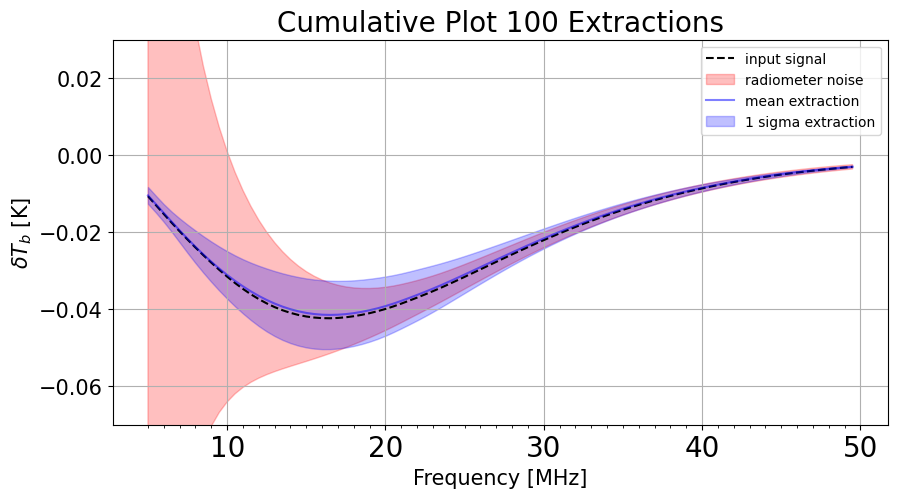

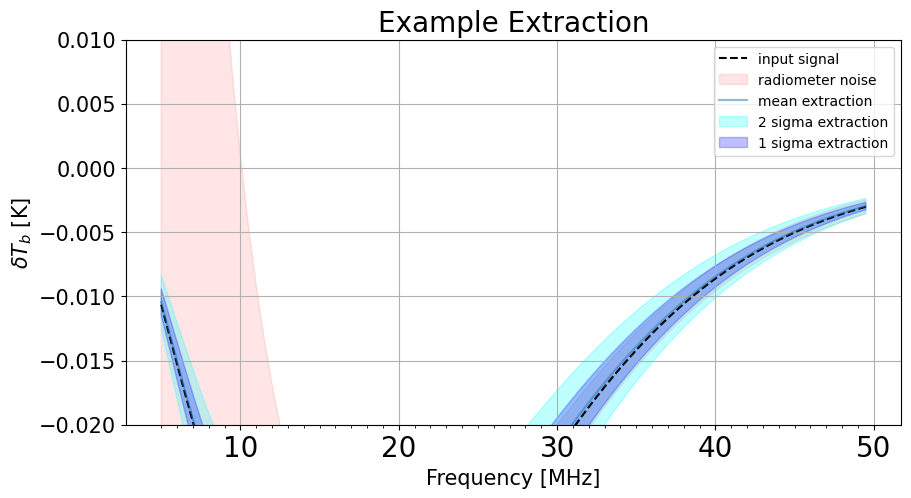

In [3]:
# Important variables:
N_extractions = 100
N_antenna = 2
n_LSTs = 10 # this should match the number of foreground_training_sets you've made
## Spectral Index Map Variable
n_regions = 8   # number of regions that are created for your multi-region model
temp1 = 20     # lower frequency that is used for the temperature for the spectral index of the spectral index map
temp2 = 50     # upper frequency
f_low = temp1   # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
f_high = temp2  # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
NSIDE = 32
## Monochromatic Beam Variables.
N_beam = 1   # Number of beams to create. I'm not varying the beam right now, but this may be helpful later.
low_std = 0.5
high_std = 0.5
## Synchrotron Foreground Variables
ylim = (-0.07,0.03)
N_TS = 1000   # Number of curves in the training set
parameter_variation = [0,0.005,0]
sky_maps = master_foreground_array
sky_maps_truncated = sky_maps[:,4:49,:]  # the trucated sky maps that map the frequency range of frequencies (though it may not match the number of bins)
frequency_range_truncated = np.arange(5,50)  # Truncated frequency range that matches the sky map frequencies
# Pylinex Extraction Variables
manual_systematics_terms = 0
manual_signal_terms = 0
N_extractions = N_extractions
num_sig_vectors = 20   # maximum number of signal modes to use in the extractions
num_sys_vectors = 75    # maximum number of systematic modes to use in the extraction
num_basis_vectors = 75  # number of basis vectors to create for the root bases (make sure its as big as the largest num_sys or num_sig_vectors number)
## signal that is used as the input to the observation data: ##
parameter_array = np.array([[omR0,0],[omM0h2,0],[omK0,0],[omL0,0],[omB0h2,0/h**2],[H0,0]])
input_signal = fiducial_signal # fiducial signal
##  ##
signal_training_set = lambdaCDM_training_set[:,16::2]  ### indexing is needed to get it into the correct shape for the extraction. Training set used in the pylinex fit


# Step 1: Create the spectral index map that will govern the B_values of the beam (since they govern the indices of the regions).
# NPIX = hp.nside2npix(NSIDE)
# spectral_maps = np.zeros((n_LSTs,NPIX))
# for l in range(n_LSTs):
#     spectral_map = py21cmsig.spectral_index_map(f_low,f_high,n_regions,temp1,temp2,NSIDE,ULSA_direction_32 = master_foreground_array[l])
#     spectral_maps[l] = spectral_map

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","w")
# f.create_dataset("spectral maps",data=spectral_maps)
# f.close()

if NSIDE != 32:
    raise ValueError ("The saved spectral maps are only 32 bit right now.")
hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","r")
spectral_maps = np.array(hdf5["spectral maps"])   # I'v visually varified that these make sense


# Step 2: Create the monochromatic beam

# monochromatic_gaussian_B_values = py21cmsig.create_monochromatic_gaussian_beam_training_set(frequencies,N_beam,[low_std,high_std],n_LSTs,n_regions,NSIDE,spectral_maps,plot_extremes = True)

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/monogaussBvalues_90fbins_10000beams","w")
# f.create_dataset("B values",data=monochromatic_gaussian_B_values[0])
# f.create_dataset("parameters",data=monochromatic_gaussian_B_values[1])
# f.close()

hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/monogaussBvalues_90fbins_10000beams","r")
monochromatic_gaussian_B_values = np.array(hdf5["B values"])   # I've visually varified that these make sense
monochromatic_gaussian_parameters = np.array(hdf5["parameters"])
if len(frequencies) != monochromatic_gaussian_B_values[0][0].shape[0]:
    raise ValueError ("Your loaded B_values do not have the same length as your frequencies. This will cause problems later")

# Step 3: Create the beam-weighted foreground training set:
## Step 3a: Create the BTS_curves to input to the foreground function:

# print("NOTE: The B_values must be massaged into a form that fits the frequency bins of the sky maps. In this case I've massaged the 90 bin B_values to fit the 45 bin sky maps")
# B_values_massaged = monochromatic_gaussian_B_values[:,:,::2,:]  ### NOTE: the ::2 allows the 90 frequency bin B_values to match the 45 frequency bins of the sky maps
# BTS_curves_monochromaticbeam = create_BTS_curves(frequencies,frequency_range_truncated,B_values_massaged,sky_maps_truncated,n_regions,spectral_index_map,n_LSTs)

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/monogaussBTS_curves_90fbins_10000beams","w")
# f.create_dataset("curves",data=BTS_curves_monochromaticbeam)
# f.close()

hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/monogaussBTS_curves_90fbins_10000beams","r")
BTS_curves_monochromaticbeam = np.array(hdf5["curves"])   # I've visually varified that these make sense

# simulated_foreground_array sets the "true sky" observations that will be compared to the training sets for the extraction. It's your data, basically. 
parameter_variation_true = [0,0,0]   
simulated_foreground_array_10LSTs = np.zeros((n_LSTs,len(frequencies)))
for l in range(n_LSTs):
    simulated_foreground_array_10LSTs[l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(1,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation_true,\
                                                                                     np.array([monochromatic_gaussian_B_values[0][l]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                       np.array([BTS_curves_monochromaticbeam[0][l]]))[0]

# The systematics training set itself
monochro_beam_TS_10LSTs = np.zeros((N_TS,n_LSTs,len(frequencies)))
for l in range(n_LSTs):
    monochro_beam_TS_10LSTs[:,l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(N_TS,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation,\
                                                                                     np.array([monochromatic_gaussian_B_values[0][l]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                       np.array([BTS_curves_monochromaticbeam[0][l]]))[0]

static_monchrome_beam_simulation=py21cmsig.multi_spectra_simulation_run(frequencies,simulated_foreground_array_10LSTs,input_signal,N_antenna,dnu,dt)

# Pylinex Extractions
data=static_monchrome_beam_simulation[0]
noise = static_monchrome_beam_simulation[5]
signal = static_monchrome_beam_simulation[1]
systematics = static_monchrome_beam_simulation[2]
test_extraction_static_monochrome = py21cmsig.extraction_statistics(N_extractions,monochro_beam_TS_10LSTs,signal_training_set,data,noise,signal,systematics,\
                                                  frequencies,multi_spectra=True,display_type = "cumulative sigmas",\
                                                    title="Cumulative Plot",num_sig_vectors=num_sig_vectors,num_sys_vectors=num_sys_vectors,\
                                                        num_basis_vectors=num_basis_vectors,ylim=ylim,sigma_plot = 1,N_antenna=N_antenna)



# single_extraction_monochromatic = py21cmsig.pylinex_extraction(monochro_beam_TS_10LSTs,signal_training_set,data,noise,signal,frequencies,\
#                                                                multi_spectra=True,num_sig_vectors=2,num_sys_vectors=num_sys_vectors,num_basis_vectors=num_basis_vectors,ylim=ylim\
#                                                                 ,man_sys_terms=manual_systematics_terms,man_sig_terms=manual_signal_terms)

mean_extraction = test_extraction_static_monochrome[15]

mean=test_extraction_static_monochrome[1]
sig1_diff = test_extraction_static_monochrome[14]
sig2_diff = 2*test_extraction_static_monochrome[14]
sig3_diff = 3*test_extraction_static_monochrome[14]
color = "tab:blue"
sigma_plot = 2
title = "Example Extraction"
ylim = (-0.02,0.01)

plt.figure(figsize=(10, 5))
plt.plot(frequencies,signal,color='black',ls="--",label="input signal")
plt.fill_between(frequencies,signal+noise[0],signal-noise[0],alpha=0.1,label="radiometer noise",color="red")
plt.plot(frequencies,mean,color=color,alpha=0.5,label="mean extraction")
if sigma_plot == 3:
    plt.fill_between(frequencies,mean-sig3_diff,mean+sig3_diff,alpha=0.25,label="3 sigma extraction",color="gray")
    plt.fill_between(frequencies,mean-sig2_diff,mean+sig2_diff,alpha=0.25,label="2 sigma extraction",color="cyan")
    plt.fill_between(frequencies,mean-sig1_diff,mean+sig1_diff,alpha=0.25,label="1 sigma extraction",color="blue")
if sigma_plot == 2:
    plt.fill_between(frequencies,mean-sig2_diff,mean+sig2_diff,alpha=0.25,label="2 sigma extraction",color="cyan")
    plt.fill_between(frequencies,mean-sig1_diff,mean+sig1_diff,alpha=0.25,label="1 sigma extraction",color="blue")
if sigma_plot == 1:
    plt.fill_between(frequencies,mean-sig1_diff,mean+sig1_diff,alpha=0.25,label="1 sigma extraction",color="blue")
        
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=20)
plt.xlabel("Frequency [MHz]",fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel(r"$\delta T_b$ [K]",fontsize=15)
plt.title(title, fontsize=20)
plt.ylim(ylim)
plt.grid()
plt.legend()


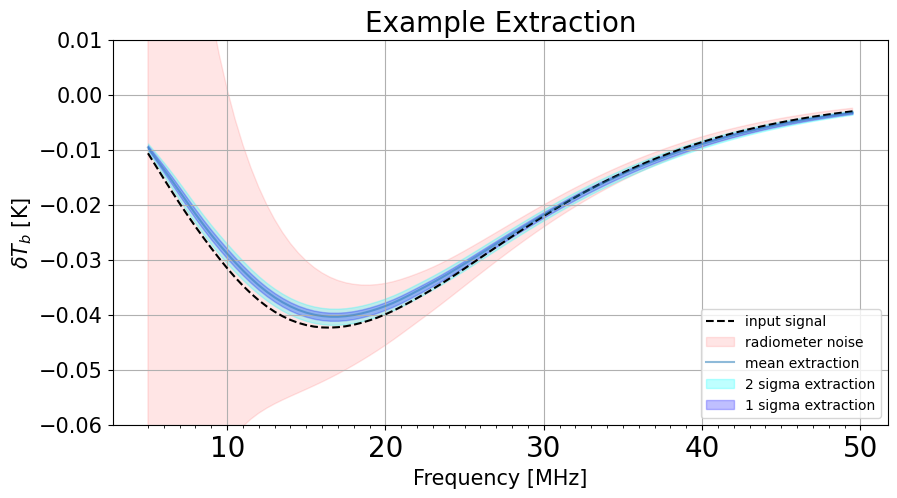

In [18]:
mean=test_extraction_static_monochrome[1]
sig1_diff = test_extraction_static_monochrome[14]
sig2_diff = 2*test_extraction_static_monochrome[14]
sig3_diff = 3*test_extraction_static_monochrome[14]
color = "tab:blue"
sigma_plot = 2
title = "Example Extraction"
ylim = (-0.06,0.01)

plt.figure(figsize=(10, 5))
plt.plot(frequencies,signal,color='black',ls="--",label="input signal")
plt.fill_between(frequencies,signal+noise[0],signal-noise[0],alpha=0.1,label="radiometer noise",color="red")
plt.plot(frequencies,mean,color=color,alpha=0.5,label="mean extraction")
if sigma_plot == 3:
    plt.fill_between(frequencies,mean-sig3_diff,mean+sig3_diff,alpha=0.25,label="3 sigma extraction",color="gray")
    plt.fill_between(frequencies,mean-sig2_diff,mean+sig2_diff,alpha=0.25,label="2 sigma extraction",color="cyan")
    plt.fill_between(frequencies,mean-sig1_diff,mean+sig1_diff,alpha=0.25,label="1 sigma extraction",color="blue")
if sigma_plot == 2:
    plt.fill_between(frequencies,mean-sig2_diff,mean+sig2_diff,alpha=0.25,label="2 sigma extraction",color="cyan")
    plt.fill_between(frequencies,mean-sig1_diff,mean+sig1_diff,alpha=0.25,label="1 sigma extraction",color="blue")
if sigma_plot == 1:
    plt.fill_between(frequencies,mean-sig1_diff,mean+sig1_diff,alpha=0.25,label="1 sigma extraction",color="blue")
        
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=20)
plt.xlabel("Frequency [MHz]",fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel(r"$\delta T_b$ [K]",fontsize=15)
plt.title(title, fontsize=20)
plt.ylim(ylim)
plt.grid()
plt.legend()

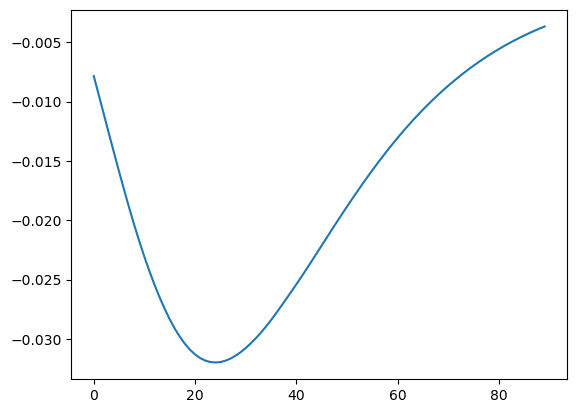

In [23]:
n=2
plt.plot(DMAN_training_set_curves[n])

100%|██████████| 100/100 [00:39<00:00,  2.52it/s]

Maximum bias of the systematics rms is 27.3227177920858
Maximum bias of the signal rms is 27.303529820698554
Average number of systematics terms used for fit: 30.35
Average number of signal terms used for fit: 1.77
Reduced Chi Squared of mean fit: [0.95838839]
Mean Reduced Chi Squared: 0.9965782550430917
STD of Reduced Chi Squared Distribution: 0.050762877190667334


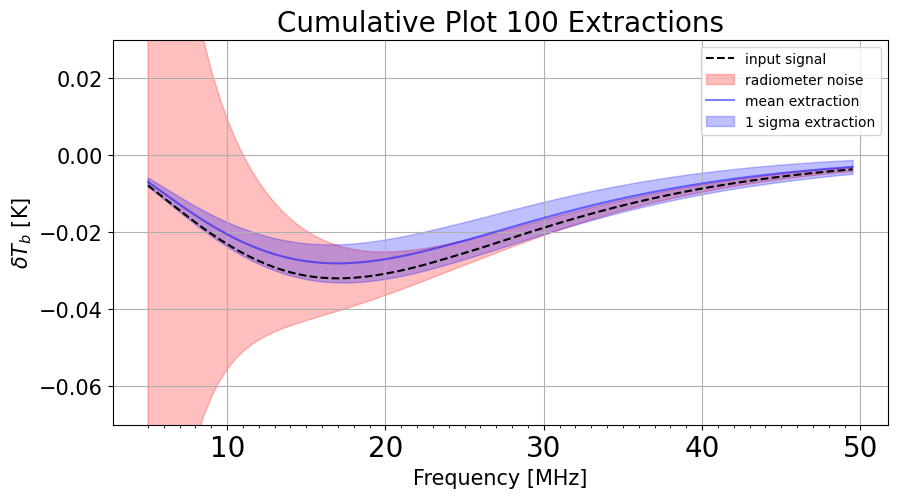

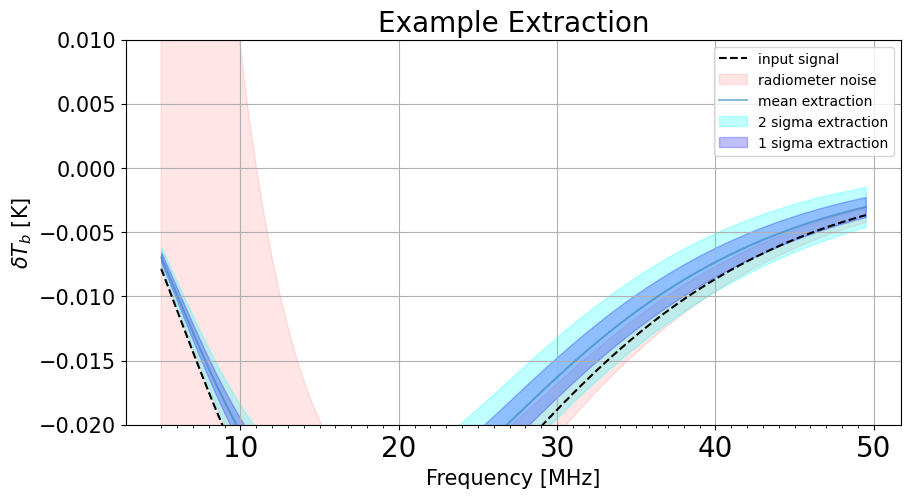

In [24]:
# Important variables:
N_extractions = 100
N_antenna = 2
n_LSTs = 10 # this should match the number of foreground_training_sets you've made
## Spectral Index Map Variable
n_regions = 8   # number of regions that are created for your multi-region model
temp1 = 20     # lower frequency that is used for the temperature for the spectral index of the spectral index map
temp2 = 50     # upper frequency
f_low = temp1   # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
f_high = temp2  # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
NSIDE = 32
## Monochromatic Beam Variables.
N_beam = 1   # Number of beams to create. I'm not varying the beam right now, but this may be helpful later.
low_std = 0.5
high_std = 0.5
## Synchrotron Foreground Variables
ylim = (-0.07,0.03)
N_TS = 1000   # Number of curves in the training set
parameter_variation = [0,0.0005,0]
sky_maps = master_foreground_array
sky_maps_truncated = sky_maps[:,4:49,:]  # the trucated sky maps that map the frequency range of frequencies (though it may not match the number of bins)
frequency_range_truncated = np.arange(5,50)  # Truncated frequency range that matches the sky map frequencies
# Pylinex Extraction Variables
manual_systematics_terms = 0
manual_signal_terms = 0
N_extractions = N_extractions
num_sig_vectors = 5  # maximum number of signal modes to use in the extractions
num_sys_vectors = 75    # maximum number of systematic modes to use in the extraction
num_basis_vectors = 75  # number of basis vectors to create for the root bases (make sure its as big as the largest num_sys or num_sig_vectors number)
## signal that is used as the input to the observation data: ##
parameter_array = np.array([[omR0,0],[omM0h2,0],[omK0,0],[omL0,0],[omB0h2,0/h**2],[H0,0]])
input_signal = DMAN_training_set_curves[2] # fiducial signal
##  ##
signal_training_set = DMAN_training_set_curves ### indexing is needed to get it into the correct shape for the extraction. Training set used in the pylinex fit


# Step 1: Create the spectral index map that will govern the B_values of the beam (since they govern the indices of the regions).
# NPIX = hp.nside2npix(NSIDE)
# spectral_maps = np.zeros((n_LSTs,NPIX))
# for l in range(n_LSTs):
#     spectral_map = py21cmsig.spectral_index_map(f_low,f_high,n_regions,temp1,temp2,NSIDE,ULSA_direction_32 = master_foreground_array[l])
#     spectral_maps[l] = spectral_map

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","w")
# f.create_dataset("spectral maps",data=spectral_maps)
# f.close()

if NSIDE != 32:
    raise ValueError ("The saved spectral maps are only 32 bit right now.")
hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","r")
spectral_maps = np.array(hdf5["spectral maps"])   # I'v visually varified that these make sense


# Step 2: Create the monochromatic beam

# monochromatic_gaussian_B_values = py21cmsig.create_monochromatic_gaussian_beam_training_set(frequencies,N_beam,[low_std,high_std],n_LSTs,n_regions,NSIDE,spectral_maps,plot_extremes = True)

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/monogaussBvalues_90fbins_10000beams","w")
# f.create_dataset("B values",data=monochromatic_gaussian_B_values[0])
# f.create_dataset("parameters",data=monochromatic_gaussian_B_values[1])
# f.close()

hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/monogaussBvalues_90fbins_10000beams","r")
monochromatic_gaussian_B_values = np.array(hdf5["B values"])   # I've visually varified that these make sense
monochromatic_gaussian_parameters = np.array(hdf5["parameters"])
if len(frequencies) != monochromatic_gaussian_B_values[0][0].shape[0]:
    raise ValueError ("Your loaded B_values do not have the same length as your frequencies. This will cause problems later")

# Step 3: Create the beam-weighted foreground training set:
## Step 3a: Create the BTS_curves to input to the foreground function:

# print("NOTE: The B_values must be massaged into a form that fits the frequency bins of the sky maps. In this case I've massaged the 90 bin B_values to fit the 45 bin sky maps")
# B_values_massaged = monochromatic_gaussian_B_values[:,:,::2,:]  ### NOTE: the ::2 allows the 90 frequency bin B_values to match the 45 frequency bins of the sky maps
# BTS_curves_monochromaticbeam = create_BTS_curves(frequencies,frequency_range_truncated,B_values_massaged,sky_maps_truncated,n_regions,spectral_index_map,n_LSTs)

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/monogaussBTS_curves_90fbins_10000beams","w")
# f.create_dataset("curves",data=BTS_curves_monochromaticbeam)
# f.close()

hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/monogaussBTS_curves_90fbins_10000beams","r")
BTS_curves_monochromaticbeam = np.array(hdf5["curves"])   # I've visually varified that these make sense

# simulated_foreground_array sets the "true sky" observations that will be compared to the training sets for the extraction. It's your data, basically. 
parameter_variation_true = [0,0,0]   
simulated_foreground_array_10LSTs = np.zeros((n_LSTs,len(frequencies)))
for l in range(n_LSTs):
    simulated_foreground_array_10LSTs[l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(1,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation_true,\
                                                                                     np.array([monochromatic_gaussian_B_values[0][l]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                       np.array([BTS_curves_monochromaticbeam[0][l]]))[0]

# The systematics training set itself
monochro_beam_TS_10LSTs = np.zeros((N_TS,n_LSTs,len(frequencies)))
for l in range(n_LSTs):
    monochro_beam_TS_10LSTs[:,l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(N_TS,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation,\
                                                                                     np.array([monochromatic_gaussian_B_values[0][l]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                       np.array([BTS_curves_monochromaticbeam[0][l]]))[0]

static_monchrome_beam_simulation=py21cmsig.multi_spectra_simulation_run(frequencies,simulated_foreground_array_10LSTs,input_signal,N_antenna,dnu,dt)

# Pylinex Extractions
data=static_monchrome_beam_simulation[0]
noise = static_monchrome_beam_simulation[5]
signal = static_monchrome_beam_simulation[1]
systematics = static_monchrome_beam_simulation[2]
test_extraction_static_monochrome = py21cmsig.extraction_statistics(N_extractions,monochro_beam_TS_10LSTs,signal_training_set,data,noise,signal,systematics,\
                                                  frequencies,multi_spectra=True,display_type = "cumulative sigmas",\
                                                    title="Cumulative Plot",num_sig_vectors=num_sig_vectors,num_sys_vectors=num_sys_vectors,\
                                                        num_basis_vectors=num_basis_vectors,ylim=ylim,sigma_plot = 1,N_antenna=N_antenna,priors=False)



# single_extraction_monochromatic = py21cmsig.pylinex_extraction(monochro_beam_TS_10LSTs,signal_training_set,data,noise,signal,frequencies,\
#                                                                multi_spectra=True,num_sig_vectors=2,num_sys_vectors=num_sys_vectors,num_basis_vectors=num_basis_vectors,ylim=ylim\
#                                                                 ,man_sys_terms=manual_systematics_terms,man_sig_terms=manual_signal_terms)

mean_extraction = test_extraction_static_monochrome[15]

mean=test_extraction_static_monochrome[1]
sig1_diff = test_extraction_static_monochrome[14]
sig2_diff = 2*test_extraction_static_monochrome[14]
sig3_diff = 3*test_extraction_static_monochrome[14]
color = "tab:blue"
sigma_plot = 2
title = "Example Extraction"
ylim = (-0.02,0.01)

plt.figure(figsize=(10, 5))
plt.plot(frequencies,signal,color='black',ls="--",label="input signal")
plt.fill_between(frequencies,signal+noise[0],signal-noise[0],alpha=0.1,label="radiometer noise",color="red")
plt.plot(frequencies,mean,color=color,alpha=0.5,label="mean extraction")
if sigma_plot == 3:
    plt.fill_between(frequencies,mean-sig3_diff,mean+sig3_diff,alpha=0.25,label="3 sigma extraction",color="gray")
    plt.fill_between(frequencies,mean-sig2_diff,mean+sig2_diff,alpha=0.25,label="2 sigma extraction",color="cyan")
    plt.fill_between(frequencies,mean-sig1_diff,mean+sig1_diff,alpha=0.25,label="1 sigma extraction",color="blue")
if sigma_plot == 2:
    plt.fill_between(frequencies,mean-sig2_diff,mean+sig2_diff,alpha=0.25,label="2 sigma extraction",color="cyan")
    plt.fill_between(frequencies,mean-sig1_diff,mean+sig1_diff,alpha=0.25,label="1 sigma extraction",color="blue")
if sigma_plot == 1:
    plt.fill_between(frequencies,mean-sig1_diff,mean+sig1_diff,alpha=0.25,label="1 sigma extraction",color="blue")
        
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=20)
plt.xlabel("Frequency [MHz]",fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel(r"$\delta T_b$ [K]",fontsize=15)
plt.title(title, fontsize=20)
plt.ylim(ylim)
plt.grid()
plt.legend()


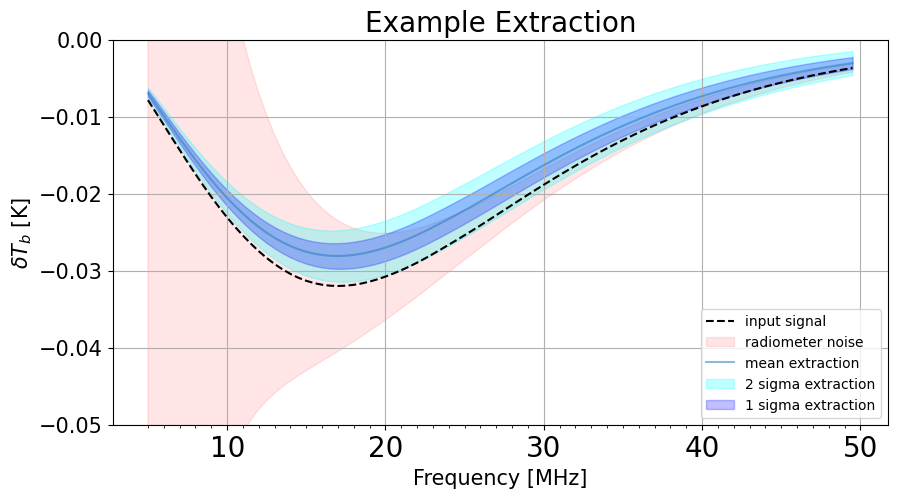

In [26]:

mean_extraction = test_extraction_static_monochrome[15]

mean=test_extraction_static_monochrome[1]
sig1_diff = test_extraction_static_monochrome[14]
sig2_diff = 2*test_extraction_static_monochrome[14]
sig3_diff = 3*test_extraction_static_monochrome[14]
color = "tab:blue"
sigma_plot = 2
title = "Example Extraction"
ylim = (-0.05,0)

plt.figure(figsize=(10, 5))
plt.plot(frequencies,signal,color='black',ls="--",label="input signal")
plt.fill_between(frequencies,signal+noise[0],signal-noise[0],alpha=0.1,label="radiometer noise",color="red")
plt.plot(frequencies,mean,color=color,alpha=0.5,label="mean extraction")
if sigma_plot == 3:
    plt.fill_between(frequencies,mean-sig3_diff,mean+sig3_diff,alpha=0.25,label="3 sigma extraction",color="gray")
    plt.fill_between(frequencies,mean-sig2_diff,mean+sig2_diff,alpha=0.25,label="2 sigma extraction",color="cyan")
    plt.fill_between(frequencies,mean-sig1_diff,mean+sig1_diff,alpha=0.25,label="1 sigma extraction",color="blue")
if sigma_plot == 2:
    plt.fill_between(frequencies,mean-sig2_diff,mean+sig2_diff,alpha=0.25,label="2 sigma extraction",color="cyan")
    plt.fill_between(frequencies,mean-sig1_diff,mean+sig1_diff,alpha=0.25,label="1 sigma extraction",color="blue")
if sigma_plot == 1:
    plt.fill_between(frequencies,mean-sig1_diff,mean+sig1_diff,alpha=0.25,label="1 sigma extraction",color="blue")
        
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=20)
plt.xlabel("Frequency [MHz]",fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel(r"$\delta T_b$ [K]",fontsize=15)
plt.title(title, fontsize=20)
plt.ylim(ylim)
plt.grid()
plt.legend()

In [48]:
static_monchrome_beam_simulation[5].shape

(10, 90)

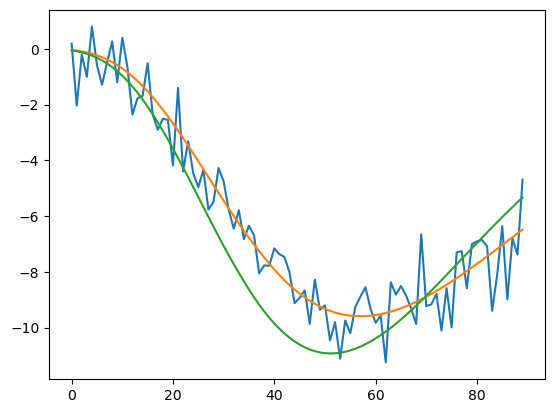

In [49]:
plt.plot((static_monchrome_beam_simulation[3][9]+static_monchrome_beam_simulation[1])/static_monchrome_beam_simulation[5][9])
plt.plot(static_monchrome_beam_simulation[1]/static_monchrome_beam_simulation[5][9])
plt.plot(fiducial_signal/static_monchrome_beam_simulation[5][9])

In [50]:
f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/Caden_data_2","w")
f.create_dataset("simulated_signal_with_noise",data=static_monchrome_beam_simulation[3][9]+static_monchrome_beam_simulation[1])
f.create_dataset("fiducial_signal",data=fiducial_signal)
f.create_dataset("signal_without_noise",data=static_monchrome_beam_simulation[1])
f.create_dataset("noise_function",data=static_monchrome_beam_simulation[5][9])
f.close()

In [ ]:
# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/Caden_data","w")
# f.create_dataset("simulated_observation",data=static_monchrome_beam_simulation[0])
# f.create_dataset("noise_function",data=static_monchrome_beam_simulation[5])
# f.create_dataset("input_signal",data=static_monchrome_beam_simulation[1])
# f.create_dataset("input_systematics",data=static_monchrome_beam_simulation[2])
# f.create_dataset("full_extraction",data=test_extraction_static_monochrome[15][0].channel_mean[810:900])
# f.create_dataset("systematic_extraction",data=test_extraction_static_monochrome[15][0].subbasis_channel_mean("systematics")[810:900])
# dset=f.create_dataset("signal_extraction",data=test_extraction_static_monochrome[15][0].subbasis_channel_mean("signal"))
# dset.attrs["reduced_chi_squared"] = test_extraction_static_monochrome[15][0].reduced_chi_squared
# dset.attrs["reduced_psi_squared"] = test_extraction_static_monochrome[15][0].psi_squared
# f.create_dataset("systematic_extraction_error",data=test_extraction_static_monochrome[15][0].subbasis_channel_error("systematics")[810:900])
# f.create_dataset("signal_extraction_error",data=test_extraction_static_monochrome[15][0].subbasis_channel_error("signal"))
# f.create_dataset("chi_squared_distribution",data=chi_squared_array)
# f.create_dataset("psi_squared_distribution",data=psi_squared_array)

# f.close()

In [198]:
test_extraction_static_monochrome[15][0].psi_squared

1.440594660878784

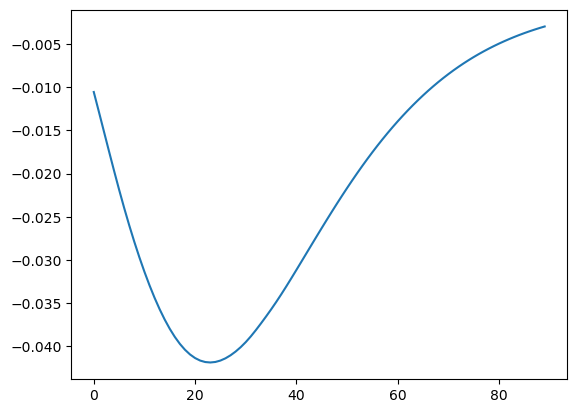

In [196]:
plt.plot(test_extraction_static_monochrome[15][0].subbasis_channel_mean("signal"))

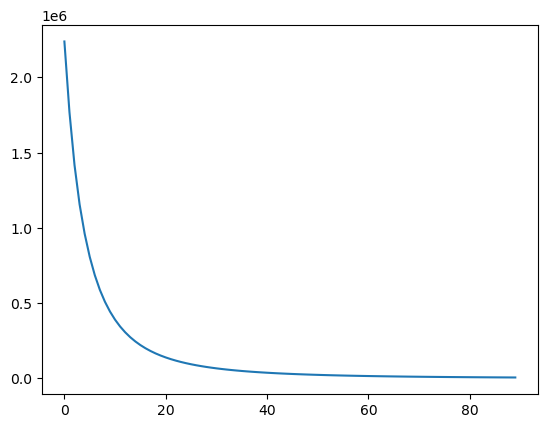

In [135]:
plt.plot(static_monchrome_beam_simulation[0][8])

In [145]:
static_monchrome_beam_simulation[4].shape

(90,)

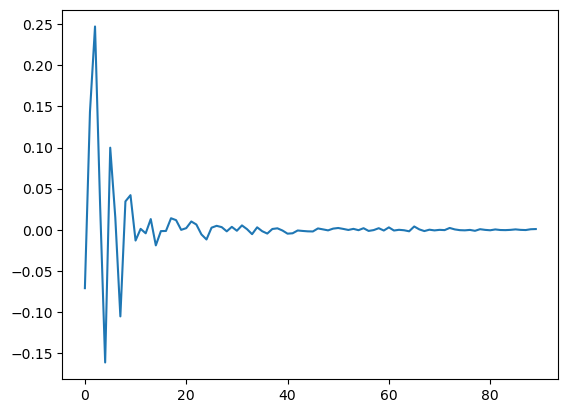

In [153]:
plt.plot(static_monchrome_beam_simulation[4]-static_monchrome_beam_simulation[0][9])

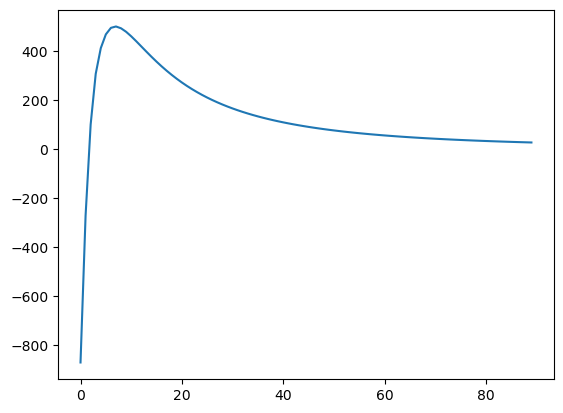

In [126]:
plt.plot(static_monchrome_beam_simulation[0][4]-static_monchrome_beam_simulation[0][2])

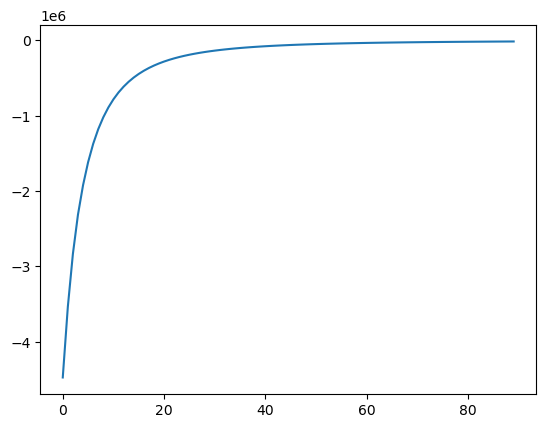

In [123]:
plt.plot(static_monchrome_beam_simulation[0][4]-static_monchrome_beam_simulation[0][1]-static_monchrome_beam_simulation[0][2]-static_monchrome_beam_simulation[0][4])

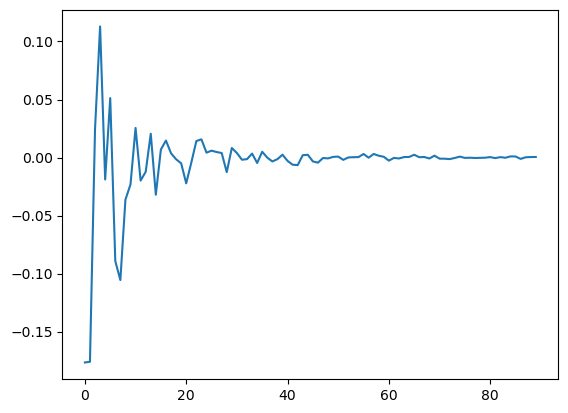

In [116]:
plt.plot(static_monchrome_beam_simulation[0][4]-(np.random.normal(static_monchrome_beam_simulation[0][4],sigT(static_monchrome_beam_simulation[0][4],N_antenna,dnu,dt))))

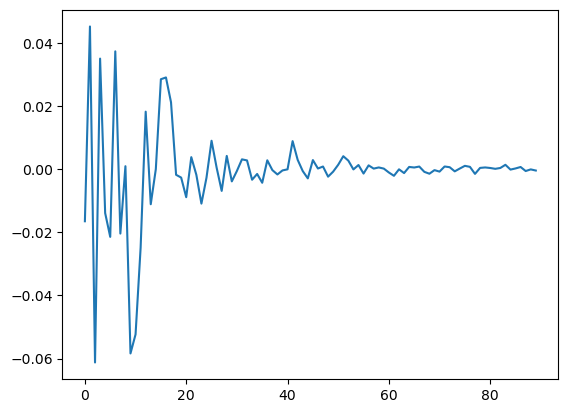

In [106]:
plt.plot(static_monchrome_beam_simulation[0][4]-(np.random.normal(static_monchrome_beam_simulation[0][4],sigT(static_monchrome_beam_simulation[0][4],N_antenna,dnu,dt))))

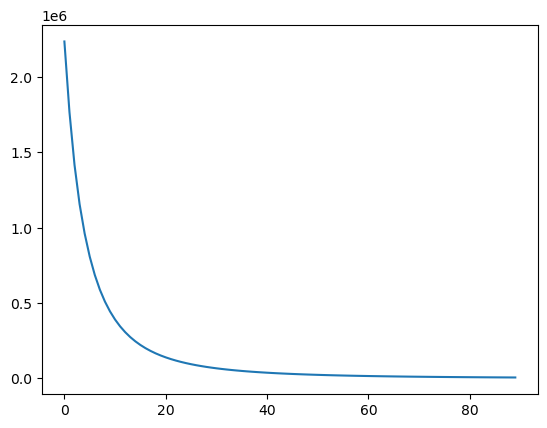

In [81]:
plt.plot(static_monchrome_beam_simulation[0][3])

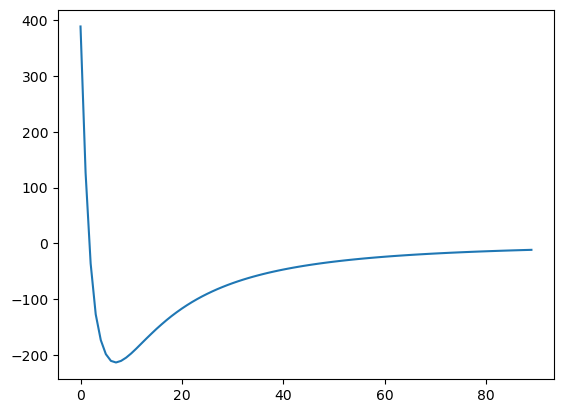

In [107]:
plt.plot(static_monchrome_beam_simulation[0][4]-static_monchrome_beam_simulation[0][0])

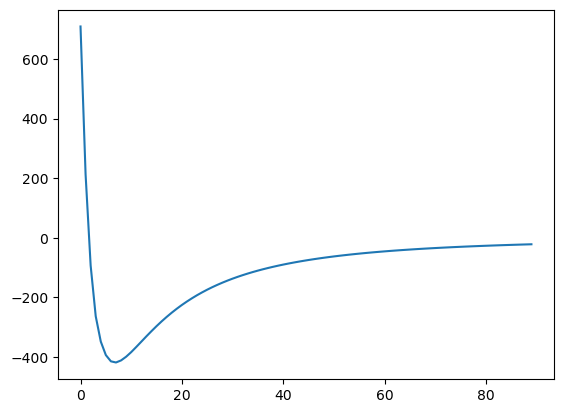

In [101]:
plt.plot(static_monchrome_beam_simulation[0][0]-static_monchrome_beam_simulation[0][3])

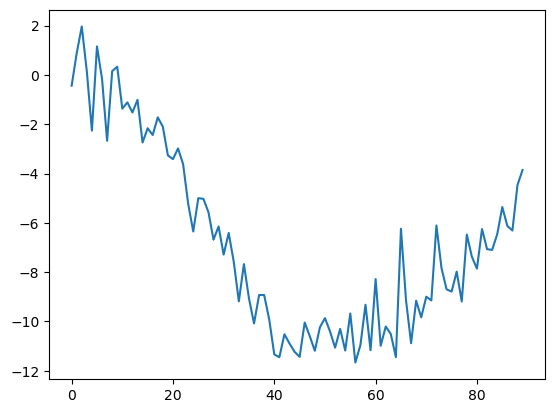

In [159]:
plt.plot((fiducial_signal+(static_monchrome_beam_simulation[4]-static_monchrome_beam_simulation[0][9]))/static_monchrome_beam_simulation[5][9])

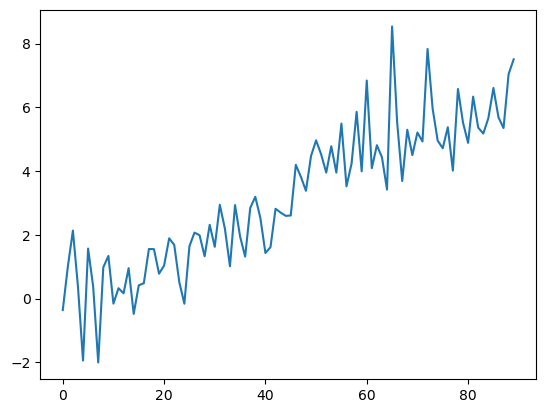

In [ ]:
plt.plot((static_monchrome_beam_simulation[1]+(static_monchrome_beam_simulation[4]-static_monchrome_beam_simulation[0][9]))/static_monchrome_beam_simulation[5][9])


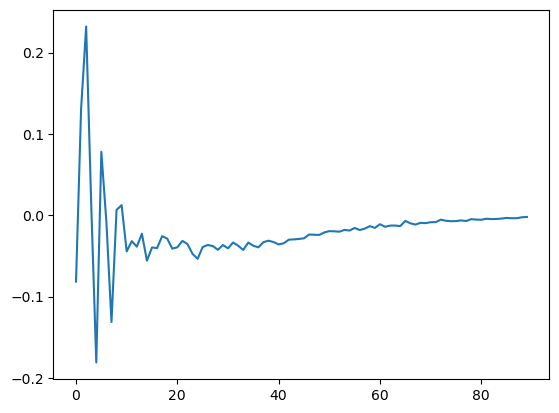

In [154]:
plt.plot(test_extraction_static_monochrome[15][0].subbasis_channel_mean("signal")+(static_monchrome_beam_simulation[4]-static_monchrome_beam_simulation[0][9]))

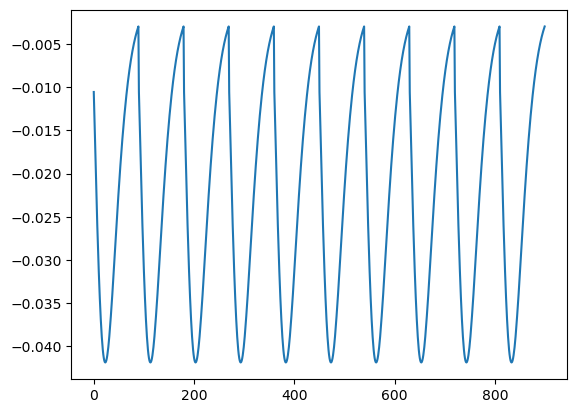

In [ ]:
plt.plot(test_extraction_static_monochrome[15][0].channel_mean-test_extraction_static_monochrome[15][0].subbasis_channel_mean("systematics"))

(array([[ 1.,  0.,  9., 79.,  0.,  0.,  0.,  0.,  0.,  1.],
        [ 1.,  2.,  9., 75.,  1.,  1.,  0.,  1.,  0.,  0.]]),
 array([-0.16150797, -0.10851473, -0.05552148, -0.00252824,  0.050465  ,
         0.10345825,  0.15645149,  0.20944474,  0.26243798,  0.31543123,
         0.36842447]),
 <a list of 2 BarContainer objects>)

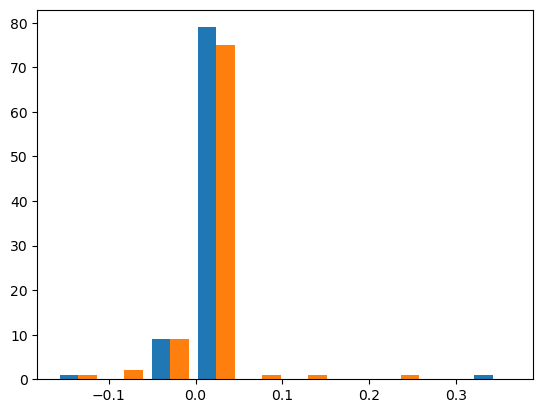

In [177]:
data1 = static_monchrome_beam_simulation[0][0]-test_extraction_static_monochrome[15][0].channel_mean[0:90]
data2 = static_monchrome_beam_simulation[4]-static_monchrome_beam_simulation[0][9]
plt.hist([data1,data2],bins=10)

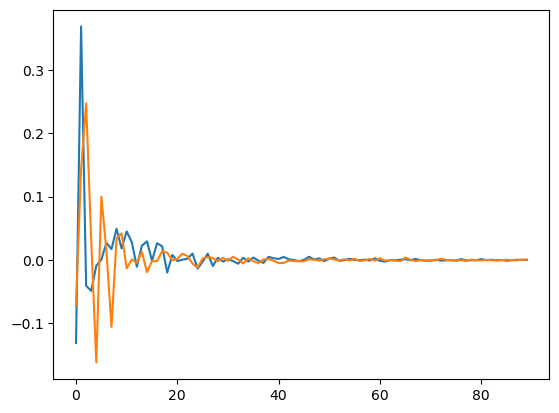

In [178]:
plt.plot(data1)
plt.plot(data2)

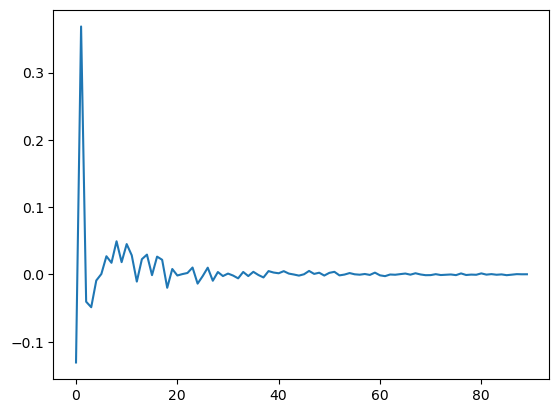

In [176]:
plt.plot(static_monchrome_beam_simulation[0][0]-test_extraction_static_monochrome[15][0].channel_mean[0:90])

In [54]:
test_extraction_static_monochrome[15][0].psi_squared

1.5177433915141632

In [55]:
test_extraction_static_monochrome[15][0].reduced_chi_squared

1.0915638464282305

(array([4.700e+01, 5.930e+02, 2.352e+03, 3.453e+03, 2.307e+03, 9.620e+02,
        2.380e+02, 4.000e+01, 6.000e+00, 2.000e+00]),
 array([0.58429436, 0.68281114, 0.78132793, 0.87984471, 0.9783615 ,
        1.07687829, 1.17539507, 1.27391186, 1.37242864, 1.47094543,
        1.56946221]),
 <BarContainer object of 10 artists>)

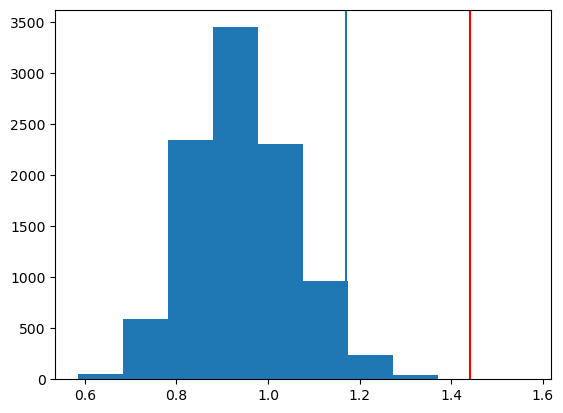

In [200]:
plt.axvline(psi_squared_array.std()*2+psi_squared_array.mean())
plt.axvline(test_extraction_static_monochrome[15][0].psi_squared,color='red')
plt.hist(psi_squared_array)

(array([2.200e+01, 2.560e+02, 1.120e+03, 2.491e+03, 3.068e+03, 2.042e+03,
        8.020e+02, 1.790e+02, 1.800e+01, 2.000e+00]),
 array([0.83984456, 0.87857706, 0.91730955, 0.95604205, 0.99477455,
        1.03350704, 1.07223954, 1.11097204, 1.14970454, 1.18843703,
        1.22716953]),
 <BarContainer object of 10 artists>)

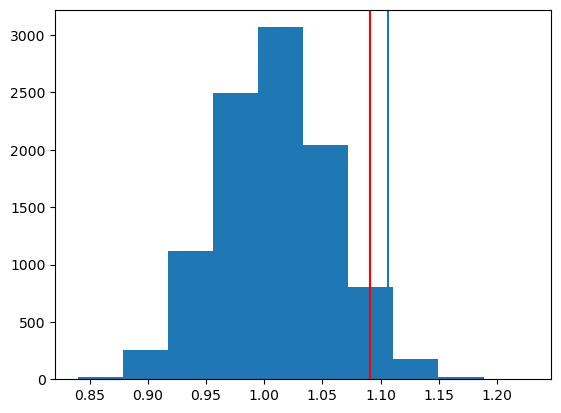

In [201]:
plt.axvline(chi_squared_array.std()*2+chi_squared_array.mean())
plt.axvline(test_extraction_static_monochrome[15][0].reduced_chi_squared,color='red')
plt.hist(chi_squared_array)

In [ ]:
# Important variables:
n_LSTs = 10 # this should match the number of foreground_training_sets you've made
## Spectral Index Map Variable
n_regions = 8   # number of regions that are created for your multi-region model
temp1 = 20     # lower frequency that is used for the temperature for the spectral index of the spectral index map
temp2 = 50     # upper frequency
f_low = temp1   # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
f_high = temp2  # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
NSIDE = 32
## Monochromatic Beam Variables.
N_beam = 1   # Number of beams to create. I'm not varying the beam right now, but this may be helpful later.
low_std = 0.5
high_std = 0.5
## Synchrotron Foreground Variables
ylim = (-0.07,0)
N_TS = 1000   # Number of curves in the training set
parameter_variation = [0,0.005,0]
sky_maps = master_foreground_array
sky_maps_truncated = sky_maps[:,4:49,:]  # the trucated sky maps that map the frequency range of frequencies (though it may not match the number of bins)
frequency_range_truncated = np.arange(5,50)  # Truncated frequency range that matches the sky map frequencies
# Pylinex Extraction Variables
manual_systematics_terms = 0
manual_signal_terms = 0
N_extractions = 10000
num_sig_vectors = 10   # maximum number of signal modes to use in the extractions
num_sys_vectors = 100    # maximum number of systematic modes to use in the extraction
num_basis_vectors = 100  # number of basis vectors to create for the root bases (make sure its as big as the largest num_sys or num_sig_vectors number)
## signal that is used as the input to the observation data: ##
parameter_array = np.array([[omR0,0],[omM0h2,0],[omK0,0],[omL0,0],[omB0h2,0/h**2],[H0,0]])
input_signal = py21cmsig.lambdaCDM_training_set(np.arange(1,50,0.5),parameter_array,1)[0][0][8:] # fiducial signal
##  ##
signal_training_set = lambdaCDM_training_set[:,16::2]  ### indexing is needed to get it into the correct shape for the extraction. Training set used in the pylinex fit


# Step 1: Create the spectral index map that will govern the B_values of the beam (since they govern the indices of the regions).
# NPIX = hp.nside2npix(NSIDE)
# spectral_maps = np.zeros((n_LSTs,NPIX))
# for l in range(n_LSTs):
#     spectral_map = py21cmsig.spectral_index_map(f_low,f_high,n_regions,temp1,temp2,NSIDE,ULSA_direction_32 = master_foreground_array[l])
#     spectral_maps[l] = spectral_map

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","w")
# f.create_dataset("spectral maps",data=spectral_maps)
# f.close()

if NSIDE != 32:
    raise ValueError ("The saved spectral maps are only 32 bit right now.")
hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","r")
spectral_maps = np.array(hdf5["spectral maps"])   # I'v visually varified that these make sense


# Step 2: Create the monochromatic beam

# monochromatic_gaussian_B_values = py21cmsig.create_monochromatic_gaussian_beam_training_set(frequencies,N_beam,[low_std,high_std],n_LSTs,n_regions,NSIDE,spectral_maps,plot_extremes = True)

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/monogaussBvalues_90fbins_10000beams","w")
# f.create_dataset("B values",data=monochromatic_gaussian_B_values[0])
# f.create_dataset("parameters",data=monochromatic_gaussian_B_values[1])
# f.close()

hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/monogaussBvalues_90fbins_10000beams","r")
monochromatic_gaussian_B_values = np.array(hdf5["B values"])   # I've visually varified that these make sense
monochromatic_gaussian_parameters = np.array(hdf5["parameters"])
if len(frequencies) != monochromatic_gaussian_B_values[0][0].shape[0]:
    raise ValueError ("Your loaded B_values do not have the same length as your frequencies. This will cause problems later")

# Step 3: Create the beam-weighted foreground training set:
## Step 3a: Create the BTS_curves to input to the foreground function:

# print("NOTE: The B_values must be massaged into a form that fits the frequency bins of the sky maps. In this case I've massaged the 90 bin B_values to fit the 45 bin sky maps")
# B_values_massaged = monochromatic_gaussian_B_values[:,:,::2,:]  ### NOTE: the ::2 allows the 90 frequency bin B_values to match the 45 frequency bins of the sky maps
# BTS_curves_monochromaticbeam = create_BTS_curves(frequencies,frequency_range_truncated,B_values_massaged,sky_maps_truncated,n_regions,spectral_index_map,n_LSTs)

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/monogaussBTS_curves_90fbins_10000beams","w")
# f.create_dataset("curves",data=BTS_curves_monochromaticbeam)
# f.close()

hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/monogaussBTS_curves_90fbins_10000beams","r")
BTS_curves_monochromaticbeam = np.array(hdf5["curves"])   # I've visually varified that these make sense

# simulated_foreground_array sets the "true sky" observations that will be compared to the training sets for the extraction. It's your data, basically. 
parameter_variation_true = [0,0,0]   
simulated_foreground_array_10LSTs = np.zeros((n_LSTs,len(frequencies)))
for l in range(n_LSTs):
    simulated_foreground_array_10LSTs[l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(1,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation_true,\
                                                                                     np.array([monochromatic_gaussian_B_values[0][l]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                       np.array([BTS_curves_monochromaticbeam[0][l]]))[0]

# The systematics training set itself
monochro_beam_TS_10LSTs = np.zeros((N_TS,n_LSTs,len(frequencies)))
for l in range(n_LSTs):
    monochro_beam_TS_10LSTs[:,l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(N_TS,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation,\
                                                                                     np.array([monochromatic_gaussian_B_values[0][l]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                       np.array([BTS_curves_monochromaticbeam[0][l]]))[0]

static_monchrome_beam_simulation=py21cmsig.multi_spectra_simulation_run(frequencies,simulated_foreground_array_10LSTs,input_signal,N_antenna,dnu,dt)

# Pylinex Extractions
data=static_monchrome_beam_simulation[0]
noise = static_monchrome_beam_simulation[5]
signal = static_monchrome_beam_simulation[1]
systematics = static_monchrome_beam_simulation[2]
test_extraction_static_monochrome_histogram = py21cmsig.extraction_statistics(N_extractions,monochro_beam_TS_10LSTs,signal_training_set,\
        data,noise,signal,systematics,frequencies,multi_spectra=True,display_type = "histogram",title="Cumulative Plot",\
        num_sig_vectors=num_sig_vectors,num_sys_vectors=num_sys_vectors,num_basis_vectors=num_basis_vectors,ylim=ylim,sigma_plot = 1,\
            IC="DIC",test_mode="goodness of fit",priors=True,vertical_lines=2)

# single_extraction_monochromatic_EDE = py21cmsig.pylinex_extraction(monochro_beam_TS_10LSTs,signal_training_set,data,noise,signal,frequencies,\
#                                                                multi_spectra=True,num_sig_vectors=2,num_sys_vectors=num_sys_vectors,num_basis_vectors=num_basis_vectors,ylim=ylim\
#                                                                 ,man_sys_terms=manual_systematics_terms,man_sig_terms=manual_signal_terms)



#let's save what we just ran
f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/10k_extractions_lambdawlambda_chi2_tenth_prange","w")
f.create_dataset("chi_squared",data=test_extraction_static_monochrome_histogram[1])
f.create_dataset("psi_squared", data=test_extraction_static_monochrome_histogram[2])
f.create_dataset("signal_terms", data=test_extraction_static_monochrome_histogram[7])
f.create_dataset("systematic_terms", data=test_extraction_static_monochrome_histogram[8])
f.close()